In [16]:
from pyrootmemo import Parameter
from pyrootmemo.materials import MultipleRoots
from pyrootmemo.geometry import FailureSurface
from pyrootmemo.models import Rbmw

# Root Bundle Model weibull (RBMw)

The Root Bundle Model with weibull distributions (RBMw) calculates the total
tensile force/reinforcement by a series of parallel roots loaded in tension. 

The two major parts of the model are: 

* Root stresses are mobilised by the displacement of one root end, while the 
other root end is assumed fixed. Stresses will depend on the root length and
(linear) root elasticity.
* Root breakage is modelled using a Weibull survival curve, describing the 
fraction of roots still intact at a given level of displacement. This 
distribution is governed by the Weibull shape parameter $\kappa$.

## Create a model object

Define some roots, using the `MultipleRoots` class. The RBMw model requires the 
following root attributes to be defined:

* Root diameter: (`diameter`)
* Root length (`length`)
* Root tensile strength (`tensile strength`)
* Root elastic stiffness (`elastic_modulus`)

In [17]:
roots = MultipleRoots(
    species = 'test_species',
    diameter = Parameter([2, 3, 4, 5], 'mm'),
    length = Parameter([1, 1, 1, 1], 'm'),
    tensile_strength = Parameter([500, 250, 100, 50], 'MPa'),
    elastic_modulus = Parameter([3000, 2800, 2000, 1500], 'MPa')
    )

Next, create an instance of the RBmw model class. Specify the assumed Weibull
shape parameter. You can expliclity define the Weibull scale parameter too, but
this is not required as it can be calculated form the known root properties.  

In [18]:
rbmw = Rbmw(roots, weibull_shape = 6.0)

## Calculations

Various calculations can be made. All results are stored in dictionary object 
in the `output` attribute of the class.

### Force (`force`)

To calculate the total tensile force in the roots at a given displacement, 
first do the calculation and then request the results from the relevant `output` 
attributes:

In [19]:
displacement = Parameter(10.0, 'cm')
rbmw.calc_force(displacement)
print(rbmw.output['displacement'])
print(rbmw.output['force'])

10.0 centimeter
147718.2840782025 centimeter * megapascal * millimeter ** 2 / meter


This also works for a sequence of displacements:

In [20]:
displacement = Parameter([5.0, 10.0, 15.0], 'cm')
rbmw.calc_force(displacement)
print(rbmw.output['displacement'])
print(rbmw.output['force'])

[5.0 10.0 15.0] centimeter
[210664.2450547112 147718.2840782025 100744.26903172536] centimeter * megapascal * millimeter ** 2 / meter


To return individual forces in each root, at each value of the defined displacement steps, set `results_per_root = True`:

In [21]:
rbmw.calc_force(displacement, results_per_root = True)
print(rbmw.output['force_per_root'])

[[47101.99367261981 91485.70541222504 100744.09219294012] [97033.41721036134 56232.578665977446 0.1768387852405828] [66425.48421065426 4.788849754480741e-13 5.424473759080932e-197] [103.34996107578665 4.23787012427957e-197 0.0]] centimeter * megapascal * millimeter ** 2 / meter


### Peak force (`peak_force`)

To calculate the total maximum tensile force the bundle of roots can carry, as well as the corresponding level of displacement:

In [22]:
rbmw.calc_peak_force()
print(rbmw.output['peak_displacement'])
print(rbmw.output['peak_force'])

0.03344010151166767 meter
2283.8906178123343 megapascal * millimeter ** 2


Calculation output can easily be converted to different units. For example,, 
to convert the calculated peak force to kilonewtons:

In [23]:
print(rbmw.output['peak_force'].to('kN'))

2.283890617812334 kilonewton


### Peak reinforcement (`peak_reinforcement`)

To calculate the peak reinforcement, the cross-sectional area of the failure
surface is required. A failure surface can be defined using the 
`FailureSurface` class:  

In [24]:
failure_surface = FailureSurface(cross_sectional_area = Parameter(2, 'm^2'))

Secondly, the orienation factor $k'$ should be defined (similar to in the 
Wu/Waldron model), which depends on the  orientation of the roots at failure 
and the angle of internal friction of the soil. By default, this set to 
$k'=1.0$ in line with most studies, but can be adjusted, for example

In [25]:
rbmw.calc_peak_reinforcement(failure_surface, k = 1.2)
print(rbmw.output['peak_displacement'])
print(rbmw.output['peak_reinforcement'])
print(rbmw.output['peak_reinforcement'].to('kPa'))

0.03344010151166767 meter
1370.3343706874005 megapascal * millimeter ** 2 / meter ** 2
1.3703343706874005 kilopascal


### Reduction factor compared to combined tensile strength of all roots (`reduction_factor`)

The FBM always calculates equal or smaller reinforcements compared calculations
made assuming all roots catastropically break at the same time. The reduction 
factor $k''$:

$$ k'' = \frac{\text{peak force}_{\text{RBMw}}}{\text{peak force}_{\text{catastropic}}} $$


In [26]:
rbmw.calc_reduction_factor()
print(rbmw.output['reduction_factor'])

0.4095689930208853


## Plotting (`plot`)

The predicted force--displacement results of the RBMw can be plotted using the 
`plot()` method.

To create a basic plot:

<Axes: xlabel='Pull-out displacement [mm]', ylabel='Total force in root bundle [N]'>

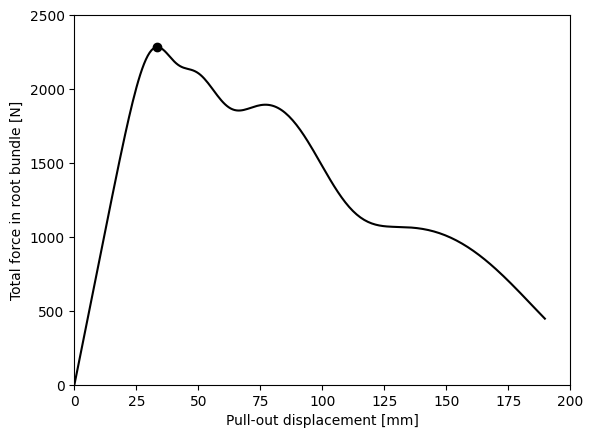

In [27]:
rbmw.plot()

You can also request to see the contribution of each individual root, and/or add labels 
indicate the index of the root in the `MultipleRoots` object, i.e. the order in
which they were defined. 

[133.27241489  71.39593655  39.98172447  26.65448298]
[[1063.2343059252307 670.24516780272 376.77309487407547  251.20990413754785] [2.2857550329560024 1196.1385941658846 787.2625625605259  527.3084175463567] [1.7178099709955499e-96 8.071562578436215 850.5874447401844  660.1696615419962] [0.0 3.885992508535361e-24 176.40128340400966 664.5214412032691]] megapascal * millimeter ** 2
[ 531.61715296 1268.31446489 1589.3293798  1770.94870383]


<Axes: xlabel='Pull-out displacement [mm]', ylabel='Total force in root bundle [N]'>

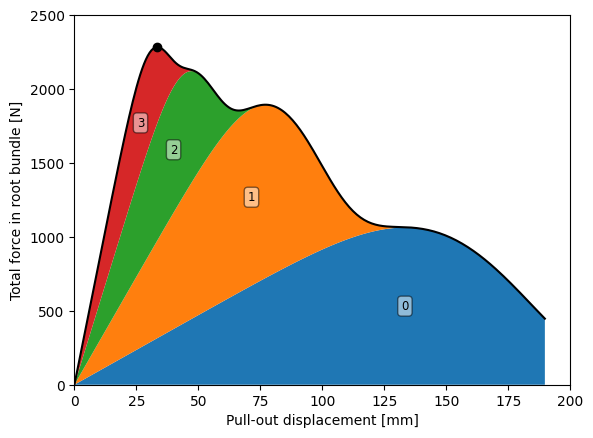

In [28]:
rbmw.plot(stack = True, labels = True)

In [30]:
a = {'a': 2}
b = 'ss'
a[b] = 3
print(a)

{'a': 2, 'ss': 3}
